<a href="https://colab.research.google.com/github/Aatif34/Deep-Learning-DS4144/blob/main/DLTutorial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
from torch.optim import SGD
import torch.nn.functional as F
from torch.utils.data import Subset, Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

print('Using PyTorch version:', torch.__version__)
if torch.cuda.is_available():
    print('Using GPU, device name:', torch.cuda.get_device_name(0))
    device = torch.device('cuda')
else:
    print('No GPU found, using CPU instead.')
    device = torch.device('cpu')

Using PyTorch version: 2.11.0+cu128
Using GPU, device name: Tesla T4


In [2]:
# Explain why we need to do this. Why do we need to give the '.ToTensor()'
# argument? What happens if we don't?

transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.23MB/s]


Check the type of data, number of data points.

In [3]:
# Size of the training set
print(trainset)
# Size of the test set
print(testset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           )


# <h4>Split into training and validation data</h4>

In [4]:
trainSize = int(0.85 * len(trainset)) # Take 85% data for training and 15% for validation
valSize = len(trainset) - trainSize
trainData, valData = torch.utils.data.random_split(trainset, [trainSize, valSize])

In [5]:
# Why do we need a DataLoadder? What would happen if we decide to skip the
# DataLoader step?

trainLoader = torch.utils.data.DataLoader(trainData, batch_size=64, shuffle=True)
valLoader = torch.utils.data.DataLoader(valData, batch_size=64, shuffle=False)
testLoader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [6]:
for (data, target) in trainLoader:
    print('data:', data.size(), 'type:', data.type())
    print('target:', target.size(), 'type:', target.type())
    break

data: torch.Size([64, 1, 28, 28]) type: torch.FloatTensor
target: torch.Size([64]) type: torch.LongTensor


Here are the first 10 training digits:

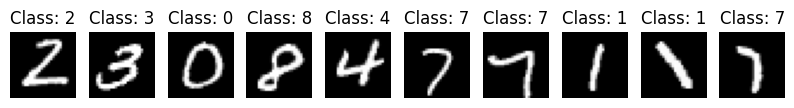

In [7]:
pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.axis('off')
    plt.imshow(data[i,:,:,:].numpy().reshape(28,28), cmap="gray")
    plt.title('Class: '+str(target[i].item()))

##Multi-layer perceptron (MLP) network

In PyTorch, a neural network is defined as a Python class. It needs to have two methods:

*   `__init__()` which initializes the layers used in the network
*   `forward()` which defines how the network performs a forward pass

PyTorch will then automatically generate a `backward()` method that computes the gradients based on the computation done in the forward pass.

All the neural network building blocks defined in PyTorch can be found in the torch.nn documentation. Use:`help(torch.nn)`

We use `nn.Sequential` to more easily create a simple sequental neural network:


*   First we need to "flatten" the 2D image into a vector with `nn.Flatten`
*   Next a fully-connected layer with 20 neurons is created with `nn.Linear`. Note that we need to specify the number of input and output connections. In this case there are 28x28=784 inputs, and 20 outputs


*   Next, a ReLU non-linear activation

*   Finally the output of the last layer needs to be a 10-dimensional vector to match the ground truth of ten classes (the ten digits).









The output of the last layer should be normalized with softmax, but this is actually included implicitly in the loss function in PyTorch (see below).

In [8]:
# Again, ask students if they know what a class definition is, and how it
# differs from a function definition. What is the use of the __init__ function
# Also, the point about how PyTorch needs a 'forward' function in a model
# class definition

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            # input norm
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.LayerNorm(128),
            nn.Linear(128,10)
            # softmax - not needed because PyTorch softmax requires
            # unnormalized logits
        )

    def forward(self, x):
        return self.layers(x)

model = SimpleMLP().to(device)
print(model)

SimpleMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)


##Training the model
\
In order to train the model we need to define a loss function and an optimizer.
\
\
For a classification task we typically use the cross entropy loss. For this we can use the class [CrossEntropyLoss](https://docs.pytorch.org/docs/2.14/generated/torch.nn.CrossEntropyLoss.html).


**Note**: if you read the documentation of `CrossEntropyLoss` carefully you will see that it expects the unnormalized raw outputs of the model as softmax is included implicitly in PyTorch's implementation of `CrossEntropyLoss`. This is why we don't need to explicitly use softmax in the network definition above.


Finally, we need to define an optimizer, which tells how to update the model parameters based on the computed gradients. There are [several different optimizer algorithms implemented in PyTorch](https://docs.pytorch.org/docs/2.14/optim.html#algorithms).

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [10]:
trainLosses, valLosses = [], []
numEpochs = 20

In [11]:
# Based on the batch size and number of samples in the training data.
# What will be the number of iterations in each epoch?(i.e. number of gradient updates)

for epoch in range(numEpochs):
    model.train()
    trainingLoss = 0
    numSamples = 0
    for images, labels in trainLoader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad() # clear old gradients
        outputs = model(images) # output after forward pass
        loss = criterion(outputs, labels)
        loss.backward()  # Backpropagation
        optimizer.step() # Update the weights
        batchSize = labels.size(0)
        trainingLoss += loss.item()*batchSize
        numSamples += batchSize

    avgLoss = trainingLoss/numSamples
    trainLosses.append(avgLoss)

    # Evaluate on validation data
    model.eval()
    valLoss = 0
    numValSamples = 0

    with torch.no_grad():
        for images, labels in valLoader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valBatchSize = labels.size(0)
            valLoss += loss.item()*valBatchSize
            numValSamples += valBatchSize

    avgValLoss = valLoss/numValSamples
    valLosses.append(avgValLoss)
    print(f'Finished Epoch {epoch}')

Finished Epoch 0
Finished Epoch 1
Finished Epoch 2
Finished Epoch 3
Finished Epoch 4
Finished Epoch 5
Finished Epoch 6
Finished Epoch 7
Finished Epoch 8
Finished Epoch 9
Finished Epoch 10
Finished Epoch 11
Finished Epoch 12
Finished Epoch 13
Finished Epoch 14
Finished Epoch 15
Finished Epoch 16
Finished Epoch 17
Finished Epoch 18
Finished Epoch 19


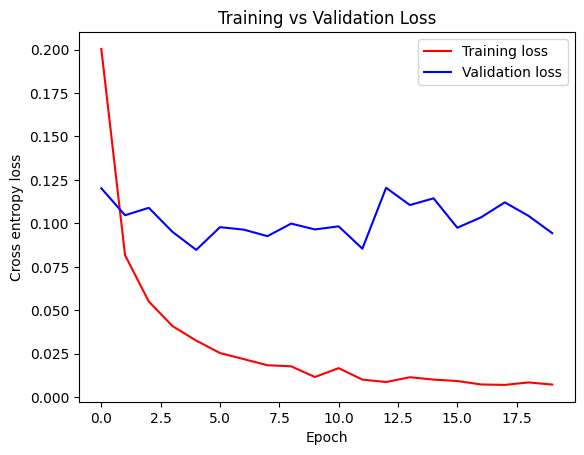

In [12]:
plt.plot(trainLosses, color='red', label='Training loss')
plt.plot(valLosses, color='blue', label='Validation loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross entropy loss')
plt.legend()
plt.show()

<h4>Evaluate on test data</h4>


In [13]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in testLoader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        values, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy = {100 * correct / total:.2f}%")

Test Accuracy = 98.33%


In [14]:
model.eval()

correct_samples = []   # The list of first 20 correct predictions
incorrect_samples = [] # The list of first 20 incorrect predictions
max_samples = 20   # To store the first 20 predictions

with torch.no_grad():
  for images, labels in testLoader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    for i in range(len(images)):
      if len(correct_samples) < max_samples and predicted[i].item() == labels[i].item():
        correct_samples.append((images[i].cpu(), labels[i].item(), predicted[i].item()))
      elif len(incorrect_samples) < max_samples and predicted[i].item() != labels[i].item():
        incorrect_samples.append((images[i].cpu(), labels[i].item(), predicted[i].item()))

      if len(correct_samples) == max_samples and len(incorrect_samples) == max_samples:
        break

    if len(correct_samples) == max_samples and len(incorrect_samples) == max_samples:
        break

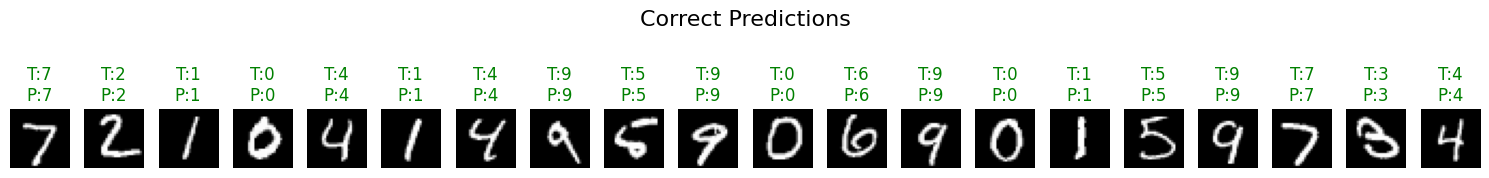

In [15]:
# Plotting correct predictions

plt.figure(figsize=(15, 3))
plt.suptitle('Correct Predictions', fontsize=16)
for i, (image, true_label, pred_label) in enumerate(correct_samples):
  plt.subplot(2, max_samples, i + 1)
  plt.imshow(image.squeeze(), cmap='gray')
  plt.title(f'T:{true_label}\nP:{pred_label}', color='green')
  plt.axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



### Displaying an image with pixel values

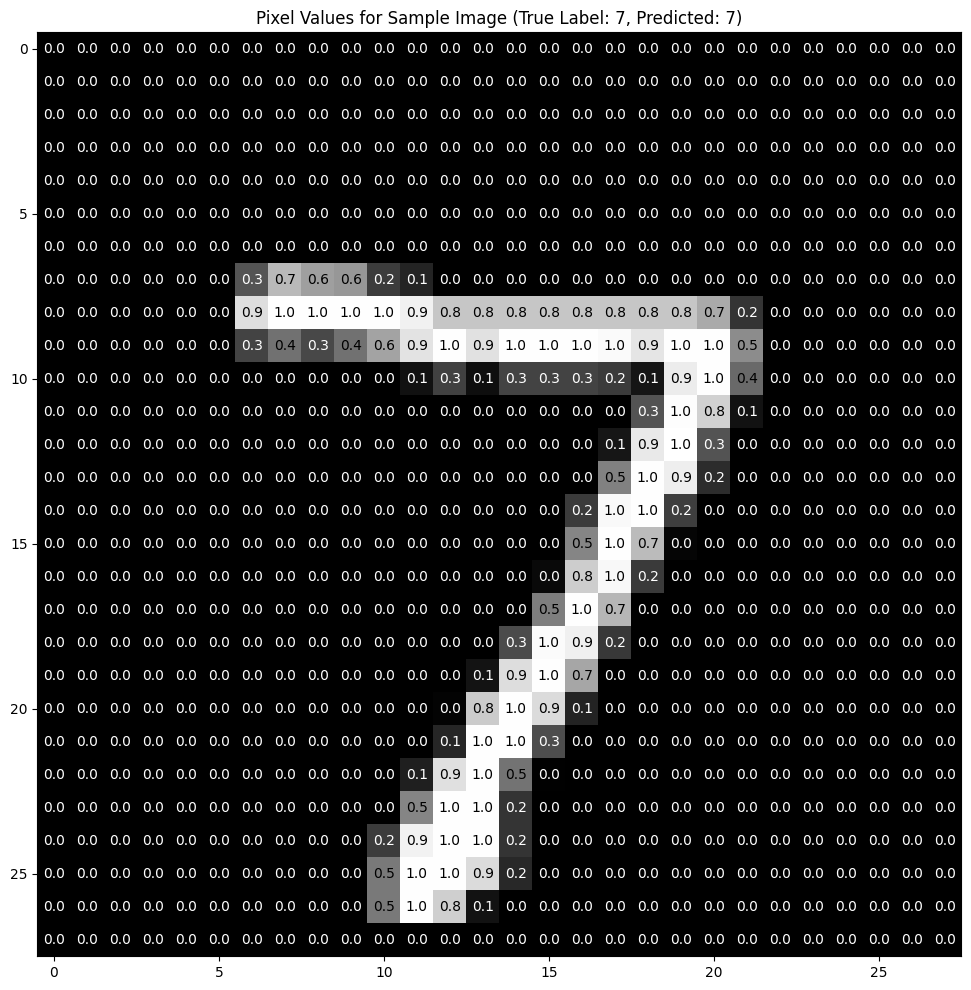

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Take the first image from correct_samples for demonstration
# The image is a tensor of shape (1, 28, 28). We need to squeeze it to (28, 28).
img = correct_samples[0][0].squeeze().numpy()

imgplot = plt.figure(figsize = (12, 12))
sub = imgplot.add_subplot(111)
sub.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max() / 2.5 # Threshold for text color to ensure readability

for x in range(width):
    for y in range(height):
        val = round(img[x][y].item(), 1)
        sub.annotate(str(val), xy=(y, x),
                     horizontalalignment='center',
                     verticalalignment='center',
                     color='white' if img[x][y].item() < thresh else 'black')

plt.title(f'Pixel Values for Sample Image (True Label: {correct_samples[0][1]}, Predicted: {correct_samples[0][2]})')
plt.show()

Tasks to do:

Q.1. Plot the incorrect prediction images.

Q.2. Change the model architecture by adding more layers.

Q.3. Look up the optimizer arguments and introduce an LR scheduler.

Q.4. What if I upload a picture of "7" but inverted; will the model be able to correctly predict it?

Q.5. Change the activation functions to tanh, sigmoid, GeLU, leaky relu, elu.

Q.6. Change the optimisers and try to improve upon the accuracy.  

Homework

1. Upload a handwritten image of your own, transform it into 28*28, convert it into grayscale and check the model's prediction.

Q.1. Plot the incorrect prediction images.

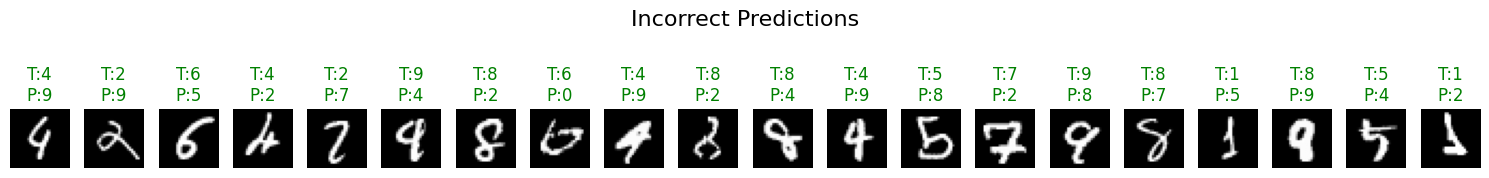

In [36]:
# Plotting Incorrect predictions

plt.figure(figsize=(15, 3))
plt.suptitle('Incorrect Predictions', fontsize=16)
for i, (image, true_label, pred_label) in enumerate(incorrect_samples):
  plt.subplot(2, max_samples, i + 1)
  plt.imshow(image.squeeze(), cmap='gray')
  plt.title(f'T:{true_label}\nP:{pred_label}', color='green')
  plt.axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Q.2. Change the model architecture by adding more layers.

In [18]:
class DeeperMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            # Input
            nn.Flatten(),

            # Layer 1
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.LayerNorm(512),

            # Layer 2
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.LayerNorm(256),

            # Layer 3
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.LayerNorm(128),

            # Layer 4
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.LayerNorm(64),

            # Output layer
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.layers(x)


model = DeeperMLP().to(device)
print(model)

DeeperMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (10): Linear(in_features=128, out_features=64, bias=True)
    (11): ReLU()
    (12): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (13): Linear(in_features=64, out_features=10, bias=True)
  )
)


Q.3. Look up the optimizer arguments and introduce an LR scheduler.

In [19]:
criterion = nn.CrossEntropyLoss()

# Adam optimizer with selected arguments
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-4
)

# Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

Q.4. What if I upload a picture of "7" but inverted; will the model be able to correctly predict it?

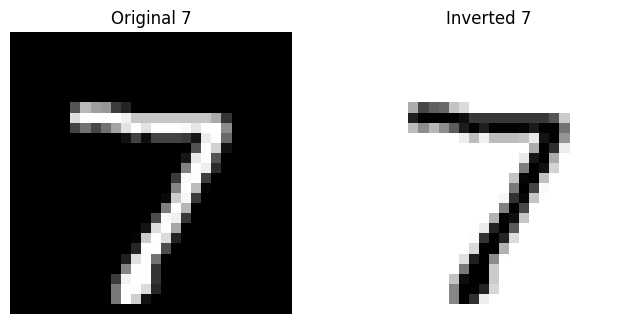

In [21]:
import matplotlib.pyplot as plt

# Find an image of digit 7
model.eval()

for images, labels in testLoader:
    for i in range(len(labels)):
        if labels[i].item() == 7:
            image = images[i]
            break
    else:
        continue
    break

# Invert the image
inverted_image = 1 - image

# Display original and inverted image
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Original 7")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(inverted_image.squeeze(), cmap="gray")
plt.title("Inverted 7")
plt.axis("off")

plt.show()

In [22]:
with torch.no_grad():
    output = model(inverted_image.unsqueeze(0).to(device))
    prediction = output.argmax(dim=1).item()

print("Predicted digit:", prediction)

Predicted digit: 9


Ansss---- The model may fail to correctly classify the inverted image because it was trained only on normal MNIST images. Inverting the pixels changes the input distribution significantly. This shows that neural networks can be sensitive to changes in image appearance even when the semantic meaning of the image remains unchanged.

Q.5. Change the activation functions to tanh, sigmoid, GeLU, leaky relu, elu.

In [23]:
class MLP(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 512),
            activation,
            nn.LayerNorm(512),

            nn.Linear(512, 256),
            activation,
            nn.LayerNorm(256),

            nn.Linear(256, 128),
            activation,
            nn.LayerNorm(128),

            nn.Linear(128, 64),
            activation,
            nn.LayerNorm(64),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.layers(x)

In [24]:
# 1. Tanh
model = MLP(nn.Tanh()).to(device)

In [25]:
# 2. Sigmoid
model = MLP(nn.Sigmoid()).to(device)

In [26]:
# 3. GELU
model = MLP(nn.GELU()).to(device)

In [27]:
# 4. Leaky ReLU
model = MLP(nn.LeakyReLU(negative_slope=0.01)).to(device)

In [28]:
# 5. ELU
model = MLP(nn.ELU(alpha=1.0)).to(device)

In [29]:
activations = {
    "Tanh": nn.Tanh(),
    "Sigmoid": nn.Sigmoid(),
    "GELU": nn.GELU(),
    "LeakyReLU": nn.LeakyReLU(0.01),
    "ELU": nn.ELU()
}

for name, activation in activations.items():
    model = MLP(activation).to(device)
    print(f"\nModel with {name}:")
    print(model)


Model with Tanh:
MLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): Tanh()
    (3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): Tanh()
    (6): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): Tanh()
    (9): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (10): Linear(in_features=128, out_features=64, bias=True)
    (11): Tanh()
    (12): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (13): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model with Sigmoid:
MLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): Sigmoid()
    (3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (4): Linear(in_features=512, out_featur

Q.6. Change the optimisers and try to improve upon the accuracy.

In [33]:
# Q.6 - Compare different optimizers

import torch
import torch.nn as nn

# Optimizer configurations
optimizer_configs = {
    "SGD": lambda model: torch.optim.SGD(
        model.parameters(),
        lr=0.01,
        momentum=0.9
    ),

    "Adam": lambda model: torch.optim.Adam(
        model.parameters(),
        lr=0.001
    ),

    "AdamW": lambda model: torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    ),

    "RMSprop": lambda model: torch.optim.RMSprop(
        model.parameters(),
        lr=0.001
    )
}

criterion = nn.CrossEntropyLoss()

results = {}

num_epochs = 10

for name, make_optimizer in optimizer_configs.items():

    # Create a fresh model for every optimizer
    model = DeeperMLP().to(device)

    optimizer = make_optimizer(model)

    # Training
    for epoch in range(num_epochs):
        model.train()

        for images, labels in trainLoader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

    # Testing
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testLoader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    accuracy = 100 * correct / total
    results[name] = accuracy

    print(f"{name}: {accuracy:.2f}%")

print("\nFinal Results:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.2f}%")

SGD: 98.10%
Adam: 97.88%
AdamW: 98.07%
RMSprop: 97.64%

Final Results:
SGD: 98.10%
Adam: 97.88%
AdamW: 98.07%
RMSprop: 97.64%


Homework

1. Upload a handwritten image of your own, transform it into 28\*28, convert it into grayscale and check the model's prediction.

Saving 0kKxxK1YXSyWMEBtS.png to 0kKxxK1YXSyWMEBtS.png


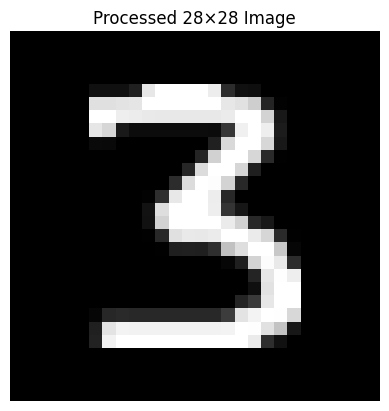

Predicted digit: 3
Confidence: 99.97%


In [35]:
# Q. Homework 1
# Upload a handwritten digit, preprocess it like an MNIST image,
# and check the model's prediction.


# Import required libraries
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
from google.colab import files


# ---------------------------------------------------------
# 1. Upload your handwritten image
# ---------------------------------------------------------

uploaded = files.upload()

# Get the name of the uploaded image
image_path = list(uploaded.keys())[0]

# Open the image and convert it to grayscale
img = Image.open(image_path).convert("L")


# ---------------------------------------------------------
# 2. Convert the image into a NumPy array
# ---------------------------------------------------------

img_array = np.array(img)


# ---------------------------------------------------------
# 3. Check the background and invert if necessary
# ---------------------------------------------------------

# MNIST images normally have:
#     Black background → 0
#     White digit      → 1
#
# If the uploaded image has a white background,
# we invert the image so that the digit becomes white
# and the background becomes black.

if img_array.mean() > 127:
    img_array = 255 - img_array


# Convert the NumPy array back to a PIL image
img = Image.fromarray(img_array.astype(np.uint8))


# ---------------------------------------------------------
# 4. Convert the digit into a black-and-white image
# ---------------------------------------------------------

# Pixels greater than 80 become white (255)
# Pixels below 80 become black (0)

img = img.point(lambda p: 255 if p > 80 else 0)


# ---------------------------------------------------------
# 5. Find and crop the handwritten digit
# ---------------------------------------------------------

# Find the bounding box containing the digit
bbox = img.getbbox()

if bbox is not None:
    img = img.crop(bbox)


# ---------------------------------------------------------
# 6. Resize the digit
# ---------------------------------------------------------

# Resize the digit while keeping its original proportions.
# Maximum size is 20 × 20 pixels.
img.thumbnail((20, 20))


# ---------------------------------------------------------
# 7. Create a 28 × 28 MNIST-style canvas
# ---------------------------------------------------------

# Create a black 28 × 28 image
canvas = Image.new("L", (28, 28), 0)


# ---------------------------------------------------------
# 8. Put the digit in the center
# ---------------------------------------------------------

# Calculate the position needed to center the digit
x = (28 - img.width) // 2
y = (28 - img.height) // 2

# Paste the digit onto the 28 × 28 black canvas
canvas.paste(img, (x, y))


# ---------------------------------------------------------
# 9. Display the processed image
# ---------------------------------------------------------

plt.imshow(canvas, cmap="gray")
plt.title("Processed 28×28 Image")
plt.axis("off")
plt.show()


# ---------------------------------------------------------
# 10. Convert the image into a PyTorch tensor
# ---------------------------------------------------------

# Convert the image to a NumPy array
# Divide by 255 to convert pixel values from:
#     0–255  →  0–1

image_tensor = torch.tensor(
    np.array(canvas) / 255.0,
    dtype=torch.float32
)


# Add dimensions required by the model:
#
# Before:
#     28 × 28
#
# After:
#     1 × 1 × 28 × 28
#
# 1st dimension = batch size
# 2nd dimension = number of channels

image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)


# ---------------------------------------------------------
# 11. Make the prediction
# ---------------------------------------------------------

# Put the model into evaluation mode
model.eval()

# Disable gradient calculation because we are only predicting
with torch.no_grad():

    # Pass the image through the trained model
    output = model(image_tensor.to(device))

    # Convert logits into probabilities
    probabilities = torch.softmax(output, dim=1)

    # Select the class with the highest probability
    prediction = output.argmax(dim=1).item()


# ---------------------------------------------------------
# 12. Display the result
# ---------------------------------------------------------

print("Predicted digit:", prediction)

# Get the confidence of the predicted class
confidence = probabilities[0, prediction].item() * 100

print(f"Confidence: {confidence:.2f}%")